In [1]:
%run ../scripts/notebook_settings.py
import sgkit as sg
import xarray as xr
import glob

In [2]:
table_desc = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/plots/SupTable_Sample_Stats_wGT_QC.tsv"
metadata_path = "~/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"

metadata_table = pd.read_csv(table_desc, sep="\t")

metadata_20x_filt = metadata_table.loc[(metadata_table.finalQC != "fail")
                              & (metadata_table.cov_chrA >= 20)
                              & (metadata_table.remove_as_relative != True)
                              & (metadata_table.remove_manual != True)
                              & (~metadata_table.ID.str.startswith("SAMEA11633"))
                             ]

In [3]:
# Loading in the kuderna mutation data and new metadata

kuderna_data = pd.read_csv("../data/science.abn7829_data_s2.csv")
# I pick out the following columns
col_species_mut = ['SPECIES_BINOMIAL', 'GENUS', 'SPECIES', 'FAMILY', 'GENERATION_LENGTH', 'MU_PER_GENERATION',
       'MU_PER_YEAR', 'EFFECTIVE_POP_SIZE']
df_species_mut = kuderna_data[col_species_mut]

metadata_dir = "/home/eriks/primatediversity/data/gVCFs_recalling_10_12_2024_metadata/"
metadata_dirs = glob.glob(metadata_dir+"*_individuals.txt")

df_l = []
for d in metadata_dirs:
    # Identify IDs
    dir_metadata = pd.read_csv(d, sep="\t")
    df_l.append(dir_metadata)
all_inds = pd.concat(df_l)

First, checking the baboon results as I have a good expectation for baboons.

In [4]:
metadata_baboons = metadata_20x_filt.loc[metadata_20x_filt.genus == "Papio"]
ind_list = [x.split("/")[3] for x in glob.glob("../steps/cobraa/*/chrX_PSMC_D50_ts4_te40*")]

In [5]:
def get_gamma_from_file(file):
    lines = !cat {file}
    return float([i for i in lines if 'gamma' in i][0].split(' ')[-1])
    
def get_LL_from_file(filename):
    with open(filename) as f:
        lines = f.readlines()
    return float([i for i in lines if 'likelihood' in i and 'final' in i][0].split(' ')[-1])

In [6]:
metadata_baboons

,ID,ID_PGDP,group,family,genus,species,subspecies,species_full,species_short,species_genotyping,...,reason,finalQC,Kuderna_AB_QC,Kuderna_COV_QC,relatives,remove_as_relative,generation,founder,remove_manual,pedigree_source
1948,SAMEA112482952,PD_0199,OWM,Cercopithecidae,Papio,anubis,ssp,Papio_anubis_ssp,P.anubis_ssp,Papio_anubis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949,SAMEA112482953,PD_0200,OWM,Cercopithecidae,Papio,anubis,ssp,Papio_anubis_ssp,P.anubis_ssp,Papio_anubis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950,SAMEA112482954,PD_0201,OWM,Cercopithecidae,Papio,anubis,ssp,Papio_anubis_ssp,P.anubis_ssp,Papio_anubis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1951,SAMEA112482955,PD_0202,OWM,Cercopithecidae,Papio,anubis,ssp,Papio_anubis_ssp,P.anubis_ssp,Papio_anubis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1952,SAMEA112482956,PD_0203,OWM,Cercopithecidae,Papio,anubis,ssp,Papio_anubis_ssp,P.anubis_ssp,Papio_anubis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2683,SAMEA112483159,PD_0692,OWM,Cercopithecidae,Papio,ursinus,ssp,Papio_ursinus_ssp,P.ursinus_ssp,Papio_ursinus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2684,SAMEA112483160,PD_0693,OWM,Cercopithecidae,Papio,ursinus,ssp,Papio_ursinus_ssp,P.ursinus_ssp,Papio_ursinus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2685,SAMEA112483161,PD_0694,OWM,Cercopithecidae,Papio,ursinus,ssp,Papio_ursinus_ssp,P.ursinus_ssp,Papio_ursinus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2686,SAMEA112483162,PD_0695,OWM,Cercopithecidae,Papio,ursinus,ssp,Papio_ursinus_ssp,P.ursinus_ssp,Papio_ursinus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


SAMN43494766 -18637545.416487016 15951856.517424647 85.58990017705565
SAMEA112483237 -21906762.000569068 18702346.00287229 85.3724799784946
SAMEA112483168 -14494906.097449701 12298998.490749514 84.8504875303294
SAMEA112483227 -23659483.25854172 20373392.884737507 86.11089541603641
SAMEA112483029 -765841.1118136889 23.070434634457342 0.0030124309440402353
SAMEA112483162 -18495471.6882069 15555711.307606842 84.10551279708908


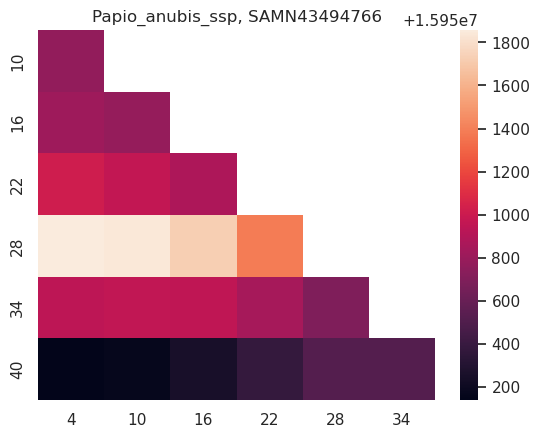

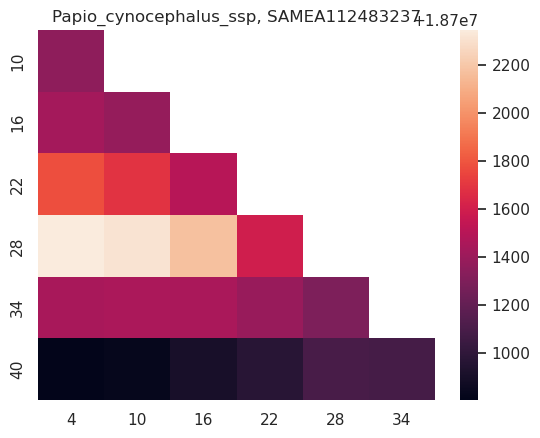

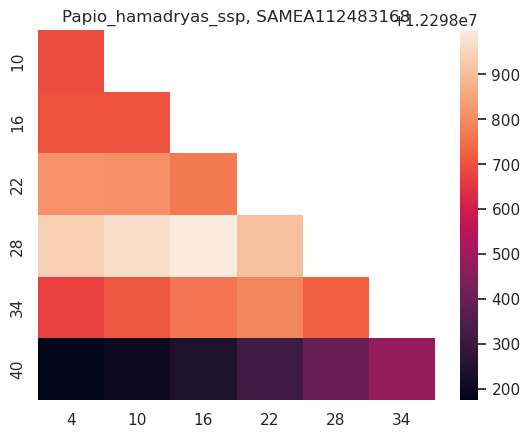

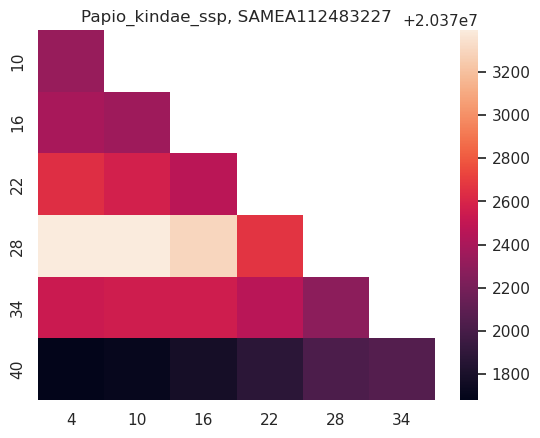

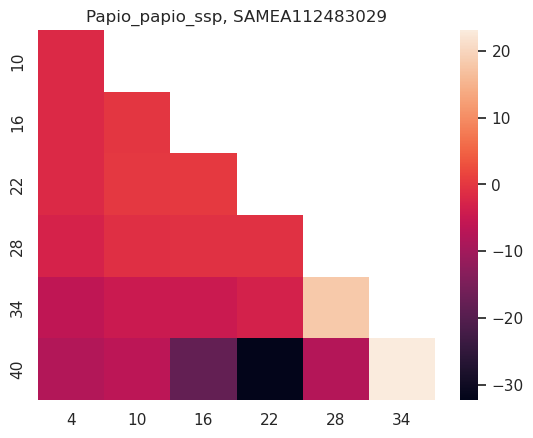

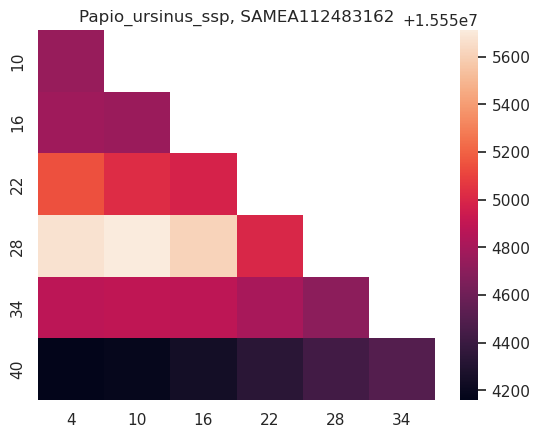

<Figure size 640x480 with 0 Axes>

In [7]:
species_df = metadata_baboons.loc[metadata_baboons.ID.isin(ind_list)]
for ind in species_df.ID:
    species = species_df.loc[species_df.ID == ind]["species_genotyping"].iloc[0]
    final_params_file_pan = f'../steps/cobraa/{ind}/aut_PSMC_final_parameters.txt'
    pan_LL = get_LL_from_file(final_params_file_pan)
    matrix_LL_diffs = np.zeros(shape=(6,6))
    matrix_LL_diffs[:] = np.nan
    for te in range(10, 42, 6):
        for ts in range(4, te-4, 6):
            final_params_file_struct = f'../steps/cobraa/{ind}/aut_PSMC_D50_ts{ts}_te{te}_final_parameters.txt'
            struct_LL = get_LL_from_file(final_params_file_struct)
            diff_LL = struct_LL - pan_LL
            matrix_LL_diffs[int((te-6)/6),int(ts/6)] = diff_LL
    matrix_LL_diffs = matrix_LL_diffs
    print(ind, pan_LL, np.nanmax(matrix_LL_diffs), -100*np.nanmax(matrix_LL_diffs)/pan_LL)
    g = sns.heatmap(matrix_LL_diffs)
    g.set(xticklabels=list(range(4, te-4, 6)), yticklabels=list(range(10, 42, 6)),title=species+", "+ind)
    plt.figure()

SAMN43494766 -18637545.416487016 18123168.932094652 97.24010607138567
SAMEA112483237 -21906762.000569068 21260624.869141955 97.05051284434309
SAMEA112483168 -14494906.097449701 14068211.294322638 97.05624306733428
SAMEA112483227 -23659483.25854172 22979893.389048465 97.1276216725997
SAMEA112483029 -765841.1118136889 611837.4227406982 79.89090861049829
SAMEA112483162 -18495471.6882069 17999595.39599441 97.3189313548101


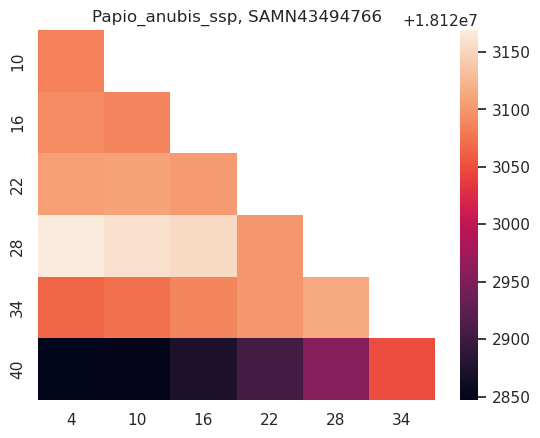

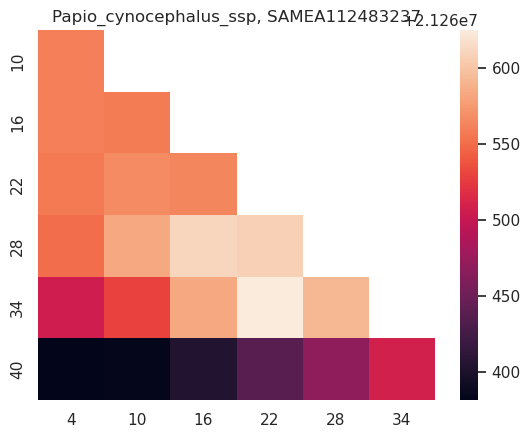

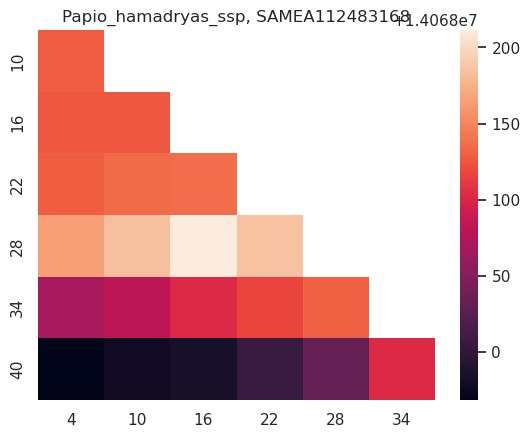

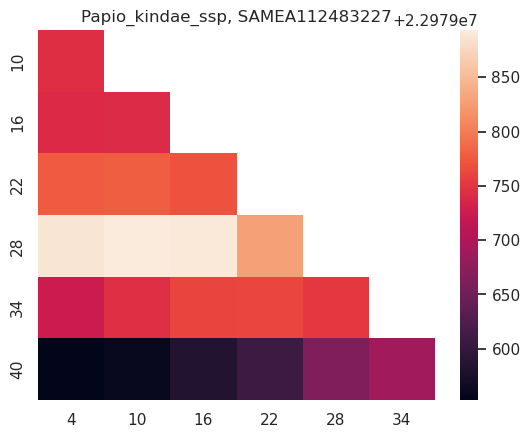

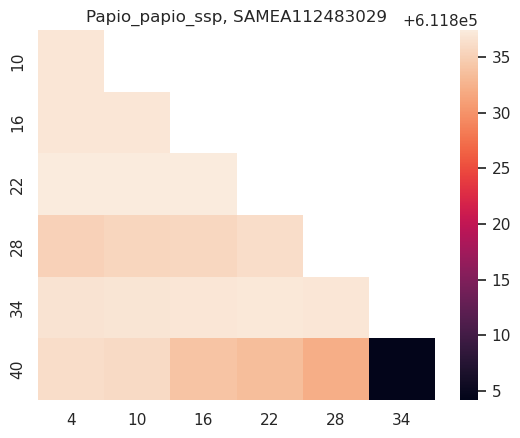

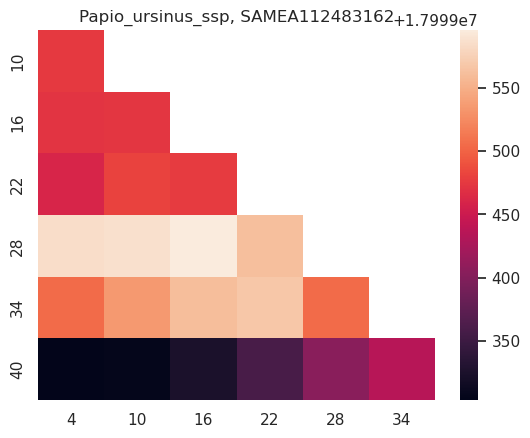

<Figure size 640x480 with 0 Axes>

In [8]:
species_df = metadata_baboons.loc[metadata_baboons.ID.isin(ind_list)]
for ind in species_df.ID:
    species = species_df.loc[species_df.ID == ind]["species_genotyping"].iloc[0]
    final_params_file_pan = f'../steps/cobraa/{ind}/aut_PSMC_final_parameters.txt'
    pan_LL = get_LL_from_file(final_params_file_pan)
    matrix_LL_diffs = np.zeros(shape=(6,6))
    matrix_LL_diffs[:] = np.nan
    for te in range(10, 42, 6):
        for ts in range(4, te-4, 6):
            final_params_file_struct = f'../steps/cobraa/{ind}/chrX_PSMC_D50_ts{ts}_te{te}_final_parameters.txt'
            struct_LL = get_LL_from_file(final_params_file_struct)
            diff_LL = struct_LL - pan_LL
            matrix_LL_diffs[int((te-6)/6),int(ts/6)] = diff_LL
    matrix_LL_diffs = matrix_LL_diffs
    print(ind, pan_LL, np.nanmax(matrix_LL_diffs), -100*np.nanmax(matrix_LL_diffs)/pan_LL)
    g = sns.heatmap(matrix_LL_diffs)
    g.set(xticklabels=list(range(4, te-4, 6)), yticklabels=list(range(10, 42, 6)),title=species+", "+ind)
    plt.figure()

Quite high variability in posterior improvement - checking the histories.

In [9]:
def find_best(file_list):
    best_param_file = None
    best_val = None
    # Go through the files and pick the 
    for p in file_list:
        LL = get_LL_from_file(p)
        if best_val == None:
            best_val = LL
            best_param_file = p
        if best_val < LL:
            best_val = LL
            best_param_file = p

    with open(best_param_file) as f:
        finallines = f.readlines()
    ztheta = float([i for i in finallines if 'theta' in i ][0].split(' ')[-1])
    zrho = float([i for i in finallines if 'rho' in i ][0].split(' ')[-1])
    zgamma = float([i for i in finallines if 'gamma' in i ][0].split(' ')[-1])
    file_name = best_param_file.split("/")[-1]
    zte = int(file_name.split("te")[1].split("_")[0])
    zts = int(file_name.split("ts")[1].split("_")[0])
    
    final_params = np.loadtxt(best_param_file)
    lambdaA_parameters = ",".join([str(x) for x in final_params[:,2]*ztheta/4])
    lambdaB_parameters = ",".join([str(x) for x in final_params[:,3]*ztheta/4])
    return zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file

28 4 0.20626905734693096 ../steps/cobraa/SAMN43494766/aut_PSMC_D50_ts4_te28_final_parameters.txt
3.91e-09 11.0
28 4 0.28429778274003287 ../steps/cobraa/SAMEA112483237/aut_PSMC_D50_ts4_te28_final_parameters.txt
5.88e-09 17.0
28 16 0.27160847100537927 ../steps/cobraa/SAMEA112483168/aut_PSMC_D50_ts16_te28_final_parameters.txt
6.08e-09 15.0
28 4 0.3110394228777214 ../steps/cobraa/SAMEA112483227/aut_PSMC_D50_ts4_te28_final_parameters.txt
7.18e-09 17.0
40 34 0.3243713814793259 ../steps/cobraa/SAMEA112483029/aut_PSMC_D50_ts34_te40_final_parameters.txt
5.04e-09 10.0
28 10 0.3099119517233681 ../steps/cobraa/SAMEA112483162/aut_PSMC_D50_ts10_te28_final_parameters.txt
6.88e-09 16.0


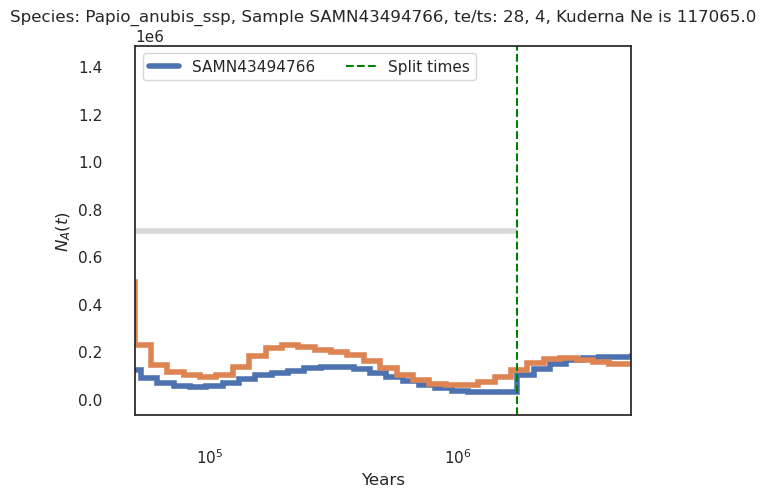

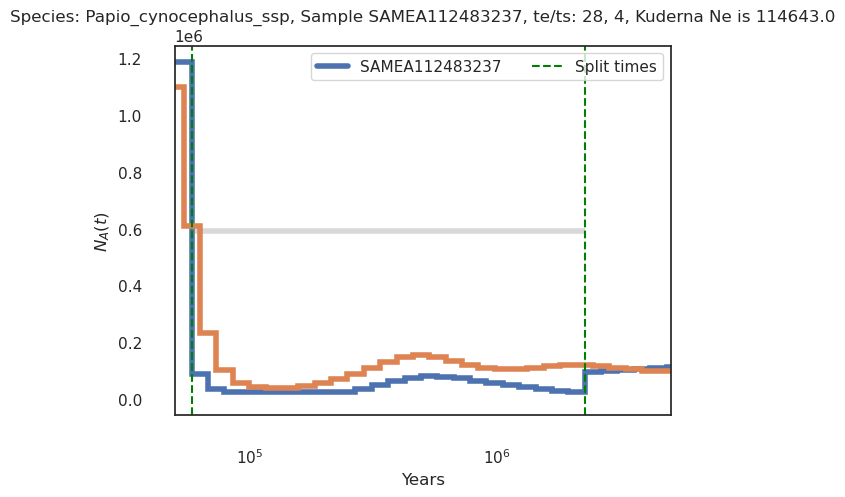

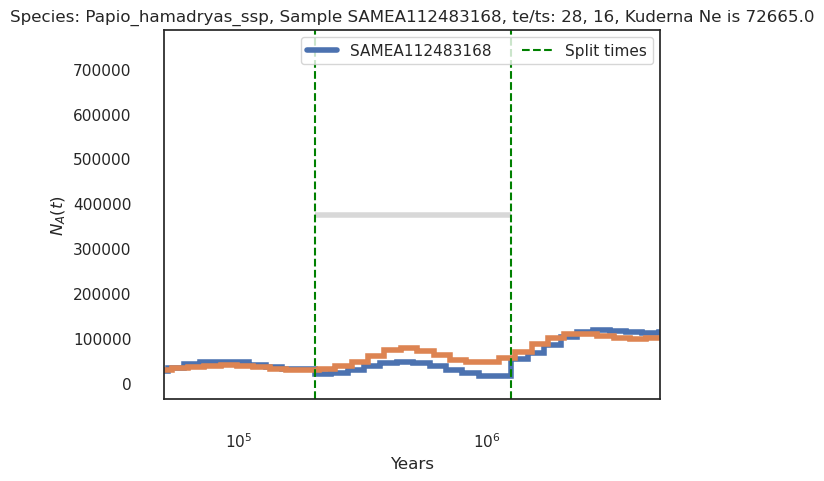

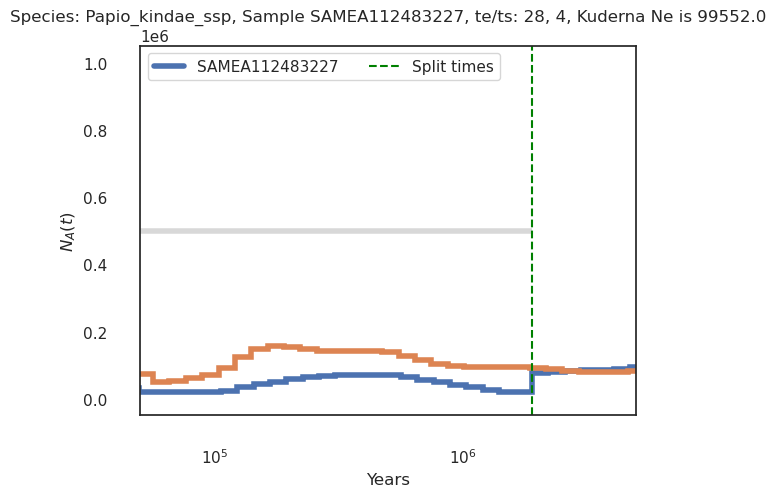

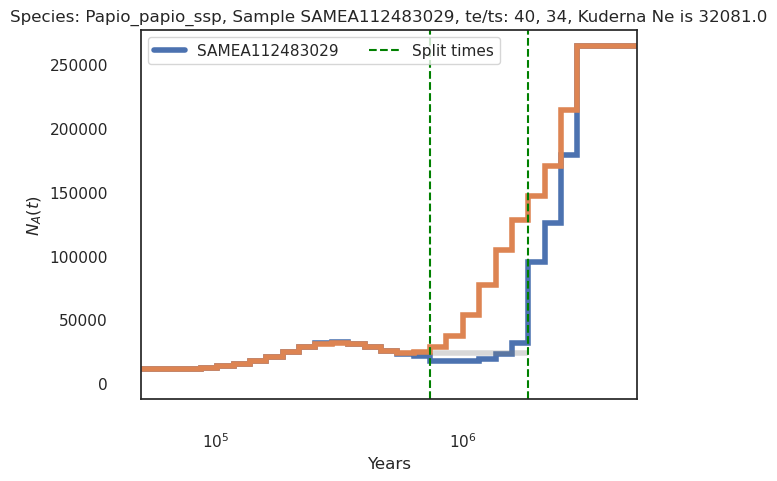

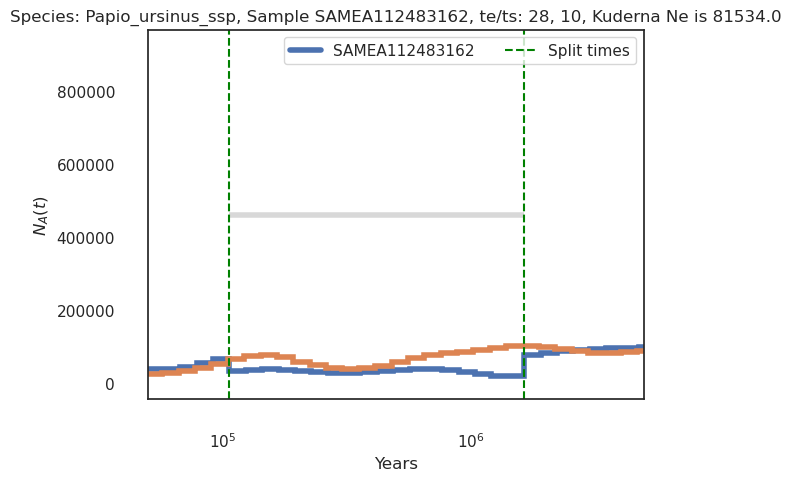

<Figure size 640x480 with 0 Axes>

In [10]:
species_df = metadata_baboons.loc[metadata_baboons.ID.isin(ind_list)]
for ind in species_df.ID:
    species = species_df.loc[species_df.ID == ind]["species_genotyping"].iloc[0]
    structured_files = glob.glob(f'../steps/cobraa/{ind}/aut_PSMC_D50_ts*_te*_final_parameters.txt')
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    label_tag = best_param_file.split("/")[-2]
    print(zte, zts, zgamma, best_param_file)
    ind_inf = all_inds.loc[all_inds.GVCF_ID == label_tag]
    gs = ind_inf.GENUS.iloc[0]+"_"+ind_inf.SPECIES.iloc[0]
    gs_df = df_species_mut.loc[df_species_mut.SPECIES_BINOMIAL == gs]
    g_df = df_species_mut.loc[df_species_mut.GENUS == ind_inf.GENUS.iloc[0]] 
    if len(gs_df) > 0:
        mu = gs_df.MU_PER_GENERATION.mean()
        gen = gs_df.GENERATION_LENGTH.mean()
        kuderna_Ne = gs_df.EFFECTIVE_POP_SIZE.mean()
    elif len(g_df) > 0:
        mu = g_df.MU_PER_GENERATION.mean()
        gen = g_df.GENERATION_LENGTH.mean()
        kuderna_Ne = g_df.EFFECTIVE_POP_SIZE.mean()
    print(mu, gen)
    final_params = np.loadtxt(best_param_file)
    time_array = list(final_params[:,1])
    time_array.insert(0,0)
    time_array = np.array(time_array)
    plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
    plt.stairs(edges=(time_array[zts:zte+1]/mu)*gen,values=(1/final_params[zts:zte,3])/mu,label='',linewidth=4,linestyle="solid",baseline=None,color="grey",alpha=0.3)
    plt.axvline((time_array[zts]/mu)*gen,color="green",linestyle="dashed")  
    plt.axvline((time_array[zte]/mu)*gen,label="Split times",color="green",linestyle="dashed")    
    plt.xlim(5e+04,5e+06)
    #plt.ylim(0,20e+04)
    plt.xscale('log')
    plt.ylabel('$N_A(t)$')
    plt.xlabel('Years')
    plt.tick_params(which='major',length=20)
    plt.tick_params(which='minor',length=10)
    plt.legend(ncol=2)
    # Unstructured for comp
    final_params = np.loadtxt(f'../steps/cobraa/{ind}/aut_PSMC_final_parameters.txt')
    time_array = list(final_params[:,1])
    time_array.insert(0,0)
    time_array = np.array(time_array)
    plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
    plt.xlim(5e+04,5e+06)
    #plt.ylim(0,20e+04)
    plt.xscale('log')
    plt.ylabel('$N_A(t)$')
    plt.xlabel('Years')
    plt.tick_params(which='major',length=20)
    plt.tick_params(which='minor',length=10)
    plt.title("Species: {}, Sample {}, te/ts: {}, {}, Kuderna Ne is {}".format(species, ind, zte, zts, kuderna_Ne))
    plt.figure()

28 4 0.42966745995684935 ../steps/cobraa/SAMN43494766/chrX_PSMC_D50_ts4_te28_final_parameters.txt
3.91e-09 11.0
34 22 0.21765812611900356 ../steps/cobraa/SAMEA112483237/chrX_PSMC_D50_ts22_te34_final_parameters.txt
5.88e-09 17.0
28 16 0.3304748213563163 ../steps/cobraa/SAMEA112483168/chrX_PSMC_D50_ts16_te28_final_parameters.txt
6.08e-09 15.0
28 10 0.2919138934220289 ../steps/cobraa/SAMEA112483227/chrX_PSMC_D50_ts10_te28_final_parameters.txt
7.18e-09 17.0
22 10 5.320180202837321e-05 ../steps/cobraa/SAMEA112483029/chrX_PSMC_D50_ts10_te22_final_parameters.txt
5.04e-09 10.0
28 16 0.27022654563139986 ../steps/cobraa/SAMEA112483162/chrX_PSMC_D50_ts16_te28_final_parameters.txt
6.88e-09 16.0


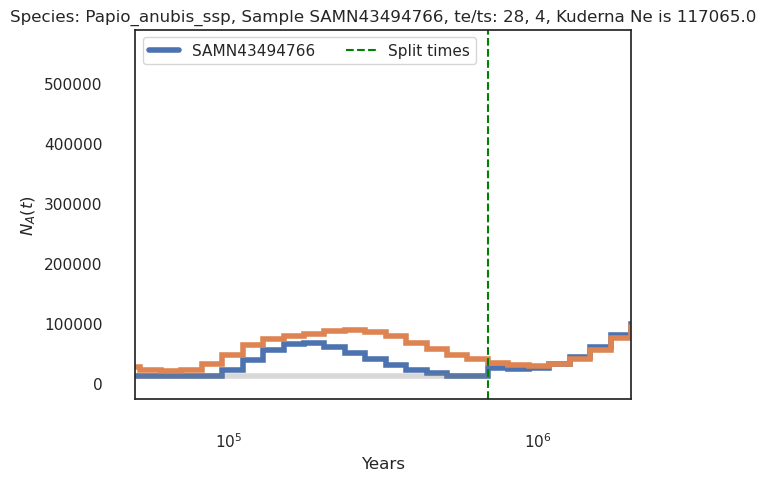

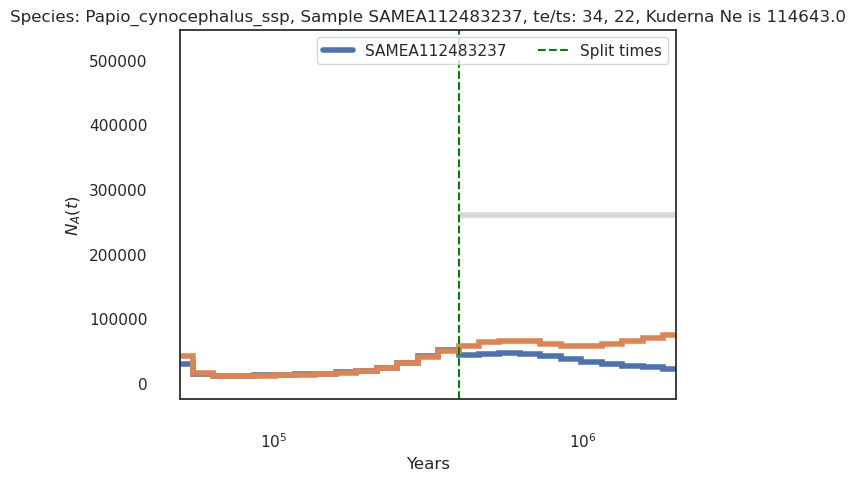

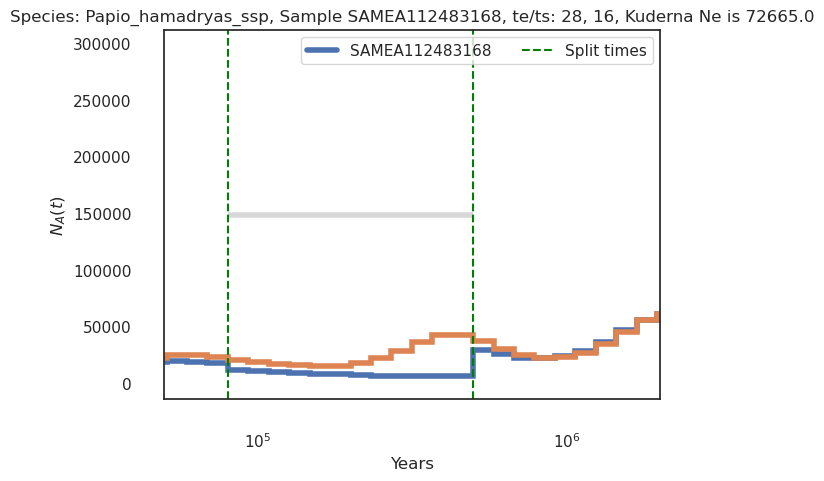

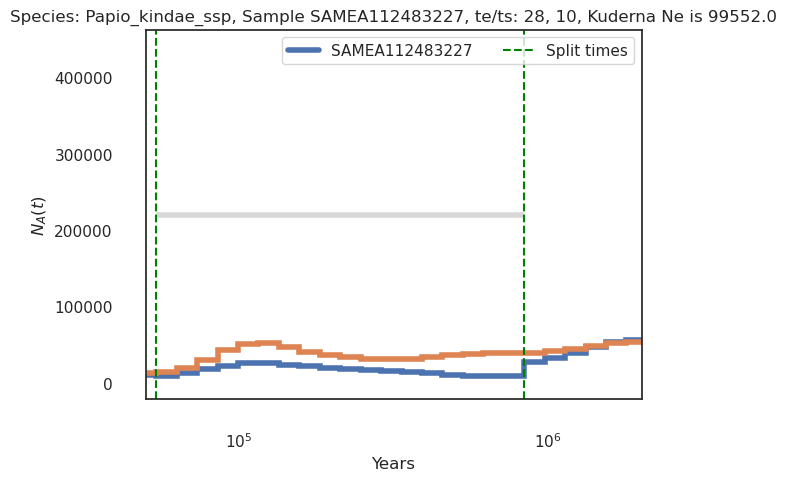

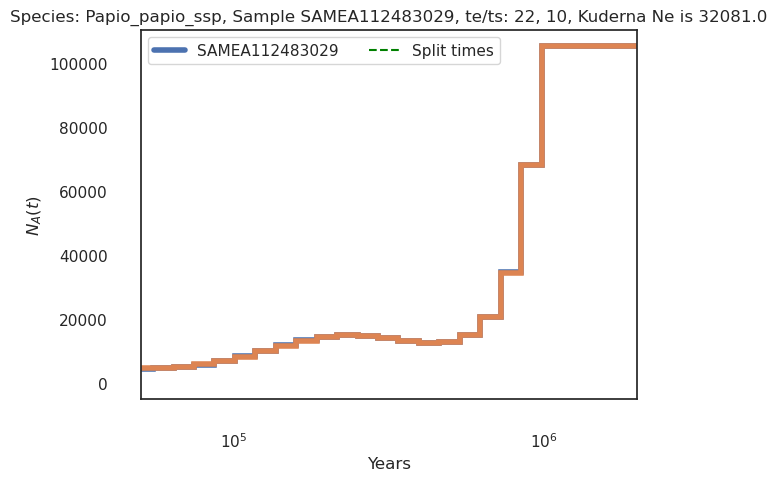

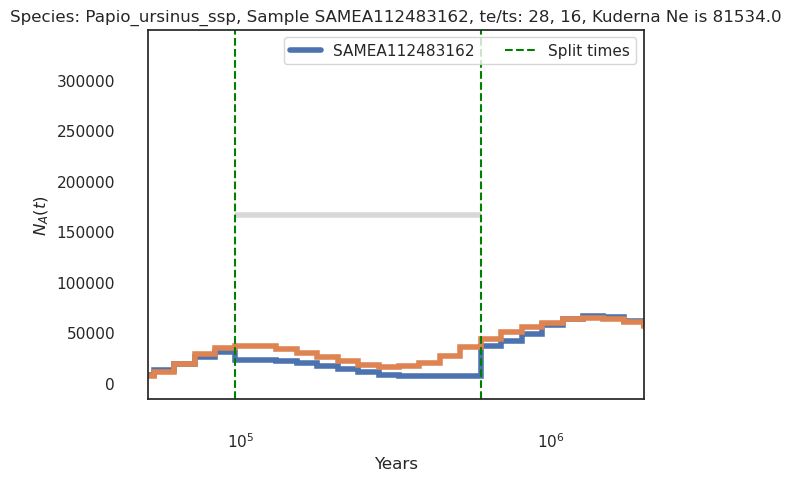

<Figure size 640x480 with 0 Axes>

In [11]:
species_df = metadata_baboons.loc[metadata_baboons.ID.isin(ind_list)]
for ind in species_df.ID:
    species = species_df.loc[species_df.ID == ind]["species_genotyping"].iloc[0]
    structured_files = glob.glob(f'../steps/cobraa/{ind}/chrX_PSMC_D50_ts*_te*_final_parameters.txt')
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    label_tag = best_param_file.split("/")[-2]
    print(zte, zts, zgamma, best_param_file)
    ind_inf = all_inds.loc[all_inds.GVCF_ID == label_tag]
    gs = ind_inf.GENUS.iloc[0]+"_"+ind_inf.SPECIES.iloc[0]
    gs_df = df_species_mut.loc[df_species_mut.SPECIES_BINOMIAL == gs]
    g_df = df_species_mut.loc[df_species_mut.GENUS == ind_inf.GENUS.iloc[0]] 
    if len(gs_df) > 0:
        mu = gs_df.MU_PER_GENERATION.mean()
        gen = gs_df.GENERATION_LENGTH.mean()
        kuderna_Ne = gs_df.EFFECTIVE_POP_SIZE.mean()
    elif len(g_df) > 0:
        mu = g_df.MU_PER_GENERATION.mean()
        gen = g_df.GENERATION_LENGTH.mean()
        kuderna_Ne = g_df.EFFECTIVE_POP_SIZE.mean()
    print(mu, gen)
    final_params = np.loadtxt(best_param_file)
    time_array = list(final_params[:,1])
    time_array.insert(0,0)
    time_array = np.array(time_array)
    plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
    plt.stairs(edges=(time_array[zts:zte+1]/mu)*gen,values=(1/final_params[zts:zte,3])/mu,label='',linewidth=4,linestyle="solid",baseline=None,color="grey",alpha=0.3)
    plt.axvline((time_array[zts]/mu)*gen,color="green",linestyle="dashed")  
    plt.axvline((time_array[zte]/mu)*gen,label="Split times",color="green",linestyle="dashed")    
    plt.xlim(5e+04,2e+06)
    #plt.ylim(0,20e+04)
    plt.xscale('log')
    plt.ylabel('$N_A(t)$')
    plt.xlabel('Years')
    plt.tick_params(which='major',length=20)
    plt.tick_params(which='minor',length=10)
    plt.legend(ncol=2)
    # Unstructured for comp
    final_params = np.loadtxt(f'../steps/cobraa/{ind}/chrX_PSMC_final_parameters.txt')
    time_array = list(final_params[:,1])
    time_array.insert(0,0)
    time_array = np.array(time_array)
    plt.stairs(edges=(time_array/mu)*gen,values=(1/final_params[:,2])/mu,label=label_tag,linewidth=4,linestyle="solid",baseline=None)
    plt.xlim(5e+04,2e+06)
    #plt.ylim(0,20e+04)
    plt.xscale('log')
    plt.ylabel('$N_A(t)$')
    plt.xlabel('Years')
    plt.tick_params(which='major',length=20)
    plt.tick_params(which='minor',length=10)
    plt.title("Species: {}, Sample {}, te/ts: {}, {}, Kuderna Ne is {}".format(species, ind, zte, zts, kuderna_Ne))
    plt.figure()

The fit improvements for baboons are not visually striking, but they could still contain some signal.

In many ways, fit improvements can be classified in two parts - first, how certain Cobraa is of the signal, and second how much signal it detects.

In [12]:
def get_all_A_indices(D_flat,ts,te, D):
    pre_struct = [i for i in range(0,ts)]
    in_struct = [ts + (j)*2 for j in range(0,te-ts)]
    post_struct = [ts + (te-ts)*2 + (j)*3 for j in range(0,D-te)]
    all_A_indices = pre_struct + in_struct + post_struct
    return all_A_indices

def get_all_B_indices(D_flat,ts,te, D):
    in_struct = [ts + ((j)*2+1) for j in range(0,te-ts)]
    post_struct = [ts + (te-ts)*2+ (j)*3+1 for j in range(0,D-te)]
    all_B_indices = in_struct + post_struct
    return all_B_indices


def get_AB_poststruct_indices(D_flat,ts,te,D):
    AB_indices = [ts + (te-ts)*2 + (j)*3+2 for j in range(0,D-te)]
    return AB_indices

def decode_posterior(zte, zts, decode_file):
    D = 50 # number of discrete time intervals in the HMM
    T_1 = zts # composite ML estimate of admixture time
    T_2 = zte # composite ML estimate of divergence time
    T_2_flat = T_1+(T_2-T_1)*2 # index of T_2 in flatten HMM transition matrix
    D_flat = T_1 + (T_2-T_1)*2 + (D-T_2)*3 # number of indices in posterior decoding; there are 32 time intervals and T_1 and T_2 are 13 and 21 respectively. Before T_1 only c=AA is possible; between T_1 and T_2 c=AA or C=BB is possible; after T_2 c=AA, c=BB and c=AB are possible
    all_A = get_all_A_indices(D_flat,T_1,T_2, D) # indices of c=AA
    all_B = get_all_B_indices(D_flat,T_1,T_2, D) # indices of c=BB ( implicitly, t>T_1 for c=BB to have non zero probability)
    all_AB = get_AB_poststruct_indices(D_flat,T_1,T_2, D) # indices of c=AB
    all_A_given_t_bigger_ts = [i for i in all_A if i>=T_1] # indices of c=AA and t>T_1
    all_A_given_t_bigger_te = [i for i in all_A if i>=T_2_flat] # indices of c=AA and t>T_2
    all_B_given_t_bigger_te = [i for i in all_B if i>=T_2_flat] # indices of c=B and t>T_2
    all_AB_given_t_bigger_te = [i for i in all_AB if i>=T_2_flat] # indices of c=AB and t>T_2
    all_A_given_t_bigger_ts_smaller_te = [i for i in all_A if i>=T_1 and i<T_2_flat] # indices of c=AA and T_1<t<T_2
    all_B_given_t_bigger_ts_smaller_te = [i for i in all_B if i>=T_1 and i<T_2_flat] # indices of c=BB and T_1<t<T_2
    t_in_structured_period = [i for i in range(T_1,T_2_flat)] # index of t for structured period
    step_size=400*25 # length between base pairs of posterior decoding
    
    decode = np.loadtxt(decode_file) # load file
    decode_position = decode[0,:] # get the genomic position
    posterior = decode[1:,:] # get the full posterior, this must sum to 1
    prob_AA_marginal = posterior[all_A,:].sum(axis=0) # P(c=AA|X)
    prob_BB_marginal = posterior[all_B,:].sum(axis=0) # P(c=BB|X)
    prob_AB_marginal = posterior[all_AB,:].sum(axis=0) # # P(c=AB|X)
    return decode_position, posterior, prob_AA_marginal, prob_BB_marginal, prob_AB_marginal


def decode_posterior_condition_t1(zte, zts, decode_file):
    D = 50 # number of discrete time intervals in the HMM
    T_1 = zts # composite ML estimate of admixture time
    T_2 = zte # composite ML estimate of divergence time
    T_2_flat = T_1+(T_2-T_1)*2 # index of T_2 in flatten HMM transition matrix
    D_flat = T_1 + (T_2-T_1)*2 + (D-T_2)*3 # number of indices in posterior decoding; there are 32 time intervals and T_1 and T_2 are 13 and 21 respectively. Before T_1 only c=AA is possible; between T_1 and T_2 c=AA or C=BB is possible; after T_2 c=AA, c=BB and c=AB are possible
    all_A = get_all_A_indices(D_flat,T_1,T_2, D) # indices of c=AA
    all_B = get_all_B_indices(D_flat,T_1,T_2, D) # indices of c=BB ( implicitly, t>T_1 for c=BB to have non zero probability)
    all_AB = get_AB_poststruct_indices(D_flat,T_1,T_2, D) # indices of c=AB
    all_A_given_t_bigger_ts = [i for i in all_A if i>=T_1] # indices of c=AA and t>T_1
    all_A_given_t_bigger_te = [i for i in all_A if i>=T_2_flat] # indices of c=AA and t>T_2
    all_B_given_t_bigger_te = [i for i in all_B if i>=T_2_flat] # indices of c=B and t>T_2
    all_AB_given_t_bigger_te = [i for i in all_AB if i>=T_2_flat] # indices of c=AB and t>T_2
    all_A_given_t_bigger_ts_smaller_te = [i for i in all_A if i>=T_1 and i<T_2_flat] # indices of c=AA and T_1<t<T_2
    all_B_given_t_bigger_ts_smaller_te = [i for i in all_B if i>=T_1 and i<T_2_flat] # indices of c=BB and T_1<t<T_2
    t_in_structured_period = [i for i in range(T_1,T_2_flat)] # index of t for structured period
    step_size=400*25 # length between base pairs of posterior decoding
    
    decode = np.loadtxt(decode_file) # load file
    decode_position = decode[0,:] # get the genomic position
    posterior = decode[1:,:] # get the full posterior, this must sum to 1
    prob_AA_marginal = posterior[all_A,:].sum(axis=0) # P(c=AA|X)
    prob_BB_marginal = posterior[all_B,:].sum(axis=0) # P(c=BB|X)
    prob_AB_marginal = posterior[all_AB,:].sum(axis=0) # # P(c=AB|X)
    prob_AA_givent_bigger_T1 = posterior[all_A_given_t_bigger_ts,:].sum(axis=0)/posterior[np.arange(T_1,D_flat,1),:].sum(axis=0) # P(c=AA|t>T_1,X)
    prob_BB_givent_bigger_T1 = posterior[all_B,:].sum(axis=0)/posterior[np.arange(T_1,D_flat,1),:].sum(axis=0) # P(c=BB|t>T_1,X)
    prob_AB_givent_bigger_T1 = posterior[all_AB,:].sum(axis=0)/posterior[np.arange(T_1,D_flat,1),:].sum(axis=0) # P(c=AB|t>T_1,X)
    return decode_position, posterior, prob_AA_givent_bigger_T1, prob_BB_givent_bigger_T1, prob_AB_givent_bigger_T1

In [13]:
# Baboon check
for ind in species_df.ID[:]:
    species = species_df.loc[species_df.ID == ind]["species_genotyping"].iloc[0]
    print(species)
    # Aut check
    structured_files = glob.glob(f'../steps/cobraa/{ind}/aut_PSMC_D50_ts*_te*_final_parameters.txt')
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    for aut in glob.glob(f"../steps/cobraa/{ind}/aut_*decode.txt")[:5]:
        decode_position, posterior, prob_AA_marginal, prob_BB_marginal, prob_AB_marginal = decode_posterior_condition_t1(zte, zts, aut)
        #print(prob_AA_marginal.sum()), print(prob_BB_marginal.sum()), print(prob_AB_marginal.sum())
        print("Aut", (prob_BB_marginal.sum()+prob_AB_marginal.sum()/2)/posterior.sum())
    # ChrX check
    structured_files = glob.glob(f'../steps/cobraa/{ind}/chrX_PSMC_D50_ts*_te*_final_parameters.txt')
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    for aut in glob.glob(f"../steps/cobraa/{ind}/chrX_*decode.txt")[:5]:
        decode_position, posterior, prob_AA_marginal, prob_BB_marginal, prob_AB_marginal = decode_posterior_condition_t1(zte, zts, aut)
        #print(prob_AA_marginal.sum()), print(prob_BB_marginal.sum()), print(prob_AB_marginal.sum())
        print("chrX", (prob_BB_marginal.sum()+prob_AB_marginal.sum()/2)/posterior.sum())

Papio_anubis_ssp
Aut 0.13233687094656027
Aut 0.15593709403567776
Aut 0.17373949961764903
Aut 0.16157691530521187
Aut 0.14180996434243304
chrX 0.42066759930230185
Papio_cynocephalus_ssp
Aut 0.3552264928016239
Aut 0.33967572359681286
Aut 0.27224616885880004
Aut 0.3158541563486921
Aut 0.26209009130208705
chrX 0.14365377242496366
Papio_hamadryas_ssp
Aut 0.2614685167653157
Aut 0.21359476534347208
Aut 0.20642856326393144
Aut 0.1843003007881721
Aut 0.19344221497859415
chrX 0.26738644955400626
Papio_kindae_ssp
Aut 0.2867137074315059
Aut 0.29868624804565946
Aut 0.3169865878878096
Aut 0.26981020091325575
Aut 0.26778421562959864
chrX 0.2761911727188323
Papio_papio_ssp
Aut 0.1969315115785121
Aut 0.20065149423438386
Aut 0.19863780650850346
Aut 0.1980569412112647
Aut 0.19872430350132167
chrX 0.0002511951849985044
Papio_ursinus_ssp
Aut 0.2733999219128613
Aut 0.2220820293924541
Aut 0.21892137033040265
Aut 0.32810704710614
Aut 0.24891187495791328
chrX 0.1966209122574045


In [14]:
# Now picking all species which both have a passing chrX and autosome.
ind_list_x = [x.split("/")[3] for x in glob.glob("../steps/cobraa/*/chrX_PSMC_final_parameters.txt")]
ind_list_aut = [x.split("/")[3] for x in glob.glob("../steps/cobraa/*/aut_PSMC_final_parameters.txt")]

In [15]:
passing_df = metadata_20x_filt.loc[(metadata_20x_filt.ID.isin(ind_list_x)) & (metadata_20x_filt.ID.isin(ind_list_aut))]
passing_df

,ID,ID_PGDP,group,family,genus,species,subspecies,species_full,species_short,species_genotyping,...,reason,finalQC,Kuderna_AB_QC,Kuderna_COV_QC,relatives,remove_as_relative,generation,founder,remove_manual,pedigree_source
2,SAMN15801446,SAMN15801446,OWM,Cercopithecidae,Allenopithecus,nigroviridis,ssp,Allenopithecus_nigroviridis_ssp,A.nigroviridis_ssp,Allenopithecus_nigroviridis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,SAMN08978235,SAMN08978235,PLA,Aotidae,Aotus,nancymaae,ssp,Aotus_nancymaae_ssp,A.nancymaae_ssp,Aotus_nancymaae_ssp,...,NaN,ok,NaN,NaN,SAMN08978237,False,P,True,NaN,30270182
52,PD_0008,PD_0008,PLA,Aotidae,Aotus,trivirgatus,ssp,Aotus_trivirgatus_ssp,A.trivirgatus_ssp,Aotus_trivirgatus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,PD_0415,PD_0415,PLA,Atelidae,Alouatta,belzebul,ssp,Alouatta_belzebul_ssp,A.belzebul_ssp,Alouatta_belzebul_ssp,...,NaN,ok,NaN,NaN,PD_0296,False,NaN,NaN,NaN,NaN
63,PD_0027,PD_0027,PLA,Atelidae,Alouatta,discolor,ssp,Alouatta_discolor_ssp,A.discolor_ssp,Alouatta_discolor_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,PD_0420,PD_0420,PLA,Atelidae,Alouatta,juara,ssp,Alouatta_juara_ssp,A.juara_ssp,Alouatta_juara_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,PD_0135,PD_0135,PLA,Atelidae,Alouatta,macconnelli,ssp,Alouatta_macconnelli_ssp,A.macconnelli_ssp,Alouatta_macconnelli_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,PD_0175,PD_0175,PLA,Atelidae,Alouatta,palliata,ssp,Alouatta_palliata_ssp,A.palliata_ssp,Alouatta_palliata_ssp,...,NaN,warn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,PD_0430,PD_0430,PLA,Atelidae,Alouatta,seniculus,puruensis,Alouatta_seniculus_puruensis,A.seniculus_puruensis,Alouatta_seniculus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,PD_0138,PD_0138,PLA,Atelidae,Ateles,belzebuth,ssp,Ateles_belzebuth_ssp,A.belzebuth_ssp,Ateles_belzebuth_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
metadata_20x_filt.genus.unique()

array(['Allenopithecus', 'Aotus', 'Alouatta', 'Ateles', 'Brachyteles',
       'Lagothrix', 'Callimico', 'Callithrix', 'Cebuella', 'Mico',
       'Carlito', 'Cephalopachus', 'Tarsius', 'Cercopithecus',
       'Cheirogaleus', 'Allochrocebus', 'Chlorocebus', 'Erythrocebus',
       'Colobus', 'Daubentonia', 'Eulemur', 'Gorilla', 'Hoolock',
       'Hylobates', 'Hapalemur', 'Lemur', 'Prolemur', 'Leontopithecus',
       'Macaca', 'Cercocebus', 'Mandrillus', 'Lepilemur', 'Microcebus',
       'Mirza', 'Miopithecus', 'Nasalis', 'Nomascus', 'Arctocebus',
       'Loris', 'Nycticebus', 'Perodicticus', 'Xanthonycticebus',
       'Galago', 'Galagoides', 'Otolemur', 'Pan', 'Lophocebus', 'Papio',
       'Piliocolobus', 'Cacajao', 'Chiropotes', 'Pithecia', 'Cheracebus',
       'Plecturocebus', 'Pongo', 'Avahi', 'Indri', 'Propithecus',
       'Presbytis', 'Pygathrix', 'Rhinopithecus', 'Leontocebus',
       'Saguinus', 'Saimiri', 'Cebus', 'Sapajus', 'Symphalangus',
       'Theropithecus', 'Semnopithecus',

In [17]:
aut.split("/")[4].split("PSMC_")[1].split("_decode")[0]

'NC_044996.1'

In [18]:
s_l, id_l, c_name_l, admixture_l, chr_type_l = [], [], [], [], []
for ind in passing_df.ID[:]:
    species = passing_df.loc[passing_df.ID == ind]["species_genotyping"].iloc[0]
    print(species)
    # Aut check
    structured_files = glob.glob(f'../steps/cobraa/{ind}/aut_PSMC_D50_ts*_te*_final_parameters.txt')
    if len(structured_files) == 0:
        continue
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    for aut in glob.glob(f"../steps/cobraa/{ind}/aut_*decode.txt")[:5]:
        decode_position, posterior, prob_AA_marginal, prob_BB_marginal, prob_AB_marginal = decode_posterior_condition_t1(zte, zts, aut)
        #print(prob_AA_marginal.sum()), print(prob_BB_marginal.sum()), print(prob_AB_marginal.sum())
        s_l.append(species), c_name_l.append(aut.split("/")[4].split("PSMC_")[1].split("_decode")[0])
        admixture_l.append((prob_BB_marginal.sum()+prob_AB_marginal.sum()/2)/posterior.sum()), chr_type_l.append("aut")
        id_l.append(ind)
        print("Aut", (prob_BB_marginal.sum()+prob_AB_marginal.sum()/2)/posterior.sum())
    # ChrX check
    structured_files = glob.glob(f'../steps/cobraa/{ind}/chrX_PSMC_D50_ts*_te*_final_parameters.txt')
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    for chrX in glob.glob(f"../steps/cobraa/{ind}/chrX_*decode.txt")[:5]:
        decode_position, posterior, prob_AA_marginal, prob_BB_marginal, prob_AB_marginal = decode_posterior_condition_t1(zte, zts, chrX)
        #print(prob_AA_marginal.sum()), print(prob_BB_marginal.sum()), print(prob_AB_marginal.sum())
        s_l.append(species), c_name_l.append(chrX.split("/")[4].split("PSMC_")[1].split("_decode")[0])
        admixture_l.append((prob_BB_marginal.sum()+prob_AB_marginal.sum()/2)/posterior.sum()), chr_type_l.append("chrX")
        id_l.append(ind)
        print("chrX", (prob_BB_marginal.sum()+prob_AB_marginal.sum()/2)/posterior.sum())

Allenopithecus_nigroviridis_ssp
Aut 0.19869321738051574
Aut 0.23147932330210644
Aut 0.24606032637917857
Aut 0.21102929365607218
Aut 0.24467007583486314
chrX 0.26283460537375986
Aotus_nancymaae_ssp
Aotus_trivirgatus_ssp
Alouatta_belzebul_ssp
Aut 0.009736513327764668
Aut 0.0758568526544697
Aut 0.032914859133621945
Aut 0.08835002684455508
Aut 0.027663072060680978
chrX 0.14281422536321414
chrX 0.1665979872958239
chrX 0.2724918725368456
chrX 0.26581655074427424
chrX 0.20612937013661833
Alouatta_discolor_ssp
Aut 0.023613291948410914
Aut 0.04083247460247444
Aut 0.22417868215375886
Aut 0.06479199174142539
Aut 0.2421045068806358
chrX 0.12505336899585454
chrX 0.05781563537319266
chrX 0.08247386254802226
chrX 0.09928215221347178
chrX 0.10824950041465099
Alouatta_juara_ssp
Aut 0.006266966092440181
Aut 0.12916849795043908
Aut 0.006727719546665995
Aut 0.10731954972415077
Aut 0.025509964872689778
chrX 0.010469274540178868
chrX 2.105163952437195e-06
chrX 0.012026360924741903
chrX 0.002969817327361542


In [19]:
admixture_df = pd.DataFrame({"species": s_l, "ID": id_l, "chrom": c_name_l,
                             "admixture_level": admixture_l, "chr_type": chr_type_l})

In [20]:
admixture_df_mean = admixture_df.groupby(["species", "chr_type"])[["admixture_level"]].mean().reset_index()

<Axes: xlabel='admixture_level', ylabel='Count'>

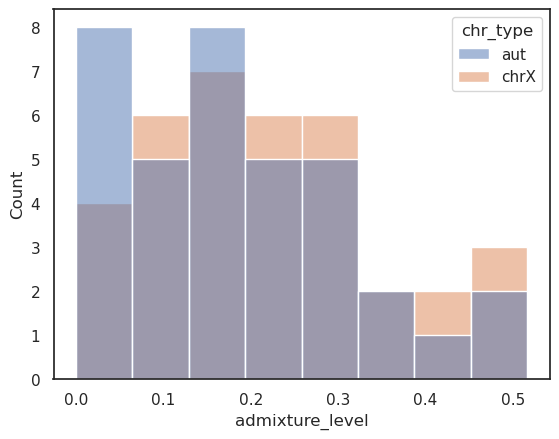

In [21]:
sns.histplot(admixture_df_mean, x="admixture_level", hue="chr_type")

In [22]:
admixture_df_mean.groupby(["chr_type"])[["admixture_level"]].mean()

,admixture_level
chr_type,
aut,0.185129
chrX,0.218743


In [23]:
df_l = []
for s in metadata_20x_filt.species_genotyping.unique():
    f_c = len(metadata_20x_filt.loc[metadata_20x_filt.gSEX == "F"])
    if f_c == 0:
        continue
    # Read het df
    pi_df_path = "../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)
    if os.path.exists("../results/window_stats_20x_inds/{}_100kb_pi.txt".format(s)):
        pi_df = pd.read_csv(pi_df_path, sep="\t")
    else:
        print("Not present:", s)
        continue
    df_l.append(pi_df)
all_pi_df = pd.concat(df_l)

In [24]:
mean_pi_df = all_pi_df.loc[all_pi_df.callable_frac >= 0.5].groupby(["species","chr_type"])[["pi"]].mean()
mean_pi_df = mean_pi_df.reset_index().pivot(columns="chr_type", index="species", values="pi")
all_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "aut"]
chrx_pi_df_aut = all_pi_df.loc[all_pi_df.chr_type == "chrX"]
mean_pi_df = mean_pi_df.reset_index()
mean_pi_df["CV_aut"] = (all_pi_df_aut.groupby(["species"])[["pi"]].std() / all_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()["pi"]
CV_x_df = (chrx_pi_df_aut.groupby(["species"])[["pi"]].std() / chrx_pi_df_aut.groupby(["species"])[["pi"]].mean()).reset_index()
mean_pi_df["CV_x"] = mean_pi_df.species.map(dict(zip(CV_x_df.species, CV_x_df.pi)))
mean_pi_df["Autosomal Pi per base"] = mean_pi_df.aut/100000
mean_pi_df["ChrX Pi per base"] = mean_pi_df.chrX/100000
mean_pi_df["X_a_ratio"] = mean_pi_df.chrX/mean_pi_df.aut
mean_pi_df["X/A ratio"] = mean_pi_df.chrX/mean_pi_df.aut

In [25]:
dict(zip(admixture_df_mean.loc[admixture_df_mean.chr_type == "chrX"].species,
 admixture_df_mean.loc[admixture_df_mean.chr_type == "chrX"].admixture_level))

{'Allenopithecus_nigroviridis_ssp': 0.26283460537375986,
 'Alouatta_belzebul_ssp': 0.21077000121535522,
 'Alouatta_discolor_ssp': 0.09457490390903844,
 'Alouatta_juara_ssp': 0.007245036966943924,
 'Alouatta_macconnelli_ssp': 0.10879257636200945,
 'Alouatta_palliata_ssp': 0.515826836089693,
 'Alouatta_seniculus_ssp': 0.11420095449322529,
 'Ateles_belzebuth_ssp': 0.16083109819555777,
 'Ateles_chamek_ssp': 0.37322318910184904,
 'Ateles_geoffroyi_ssp': 0.10214340436374394,
 'Ateles_marginatus_ssp': 0.2843549256178758,
 'Brachyteles_hypoxanthus_ssp': 0.22774930006294336,
 'Callithrix_jacchus_ssp': 0.18818918249156347,
 'Cebuella_niveiventris_ssp': 0.07717775464245881,
 'Cercopithecus_ascanius_ssp': 0.20277874046246142,
 'Cercopithecus_denti_ssp': 0.032288656845295104,
 'Cercopithecus_hamlyni_ssp': 0.46218683041001657,
 'Cercopithecus_mitis_ssp': 0.06562582858576957,
 'Cercopithecus_mona_ssp': 0.3015275360322374,
 'Cercopithecus_roloway_ssp': 0.17345157366623543,
 'Cercopithecus_wolfi_ssp': 

In [26]:
mean_pi_df["chrX_admix"] =  mean_pi_df.species.map(dict(zip(admixture_df_mean.loc[admixture_df_mean.chr_type == "chrX"].species,
 admixture_df_mean.loc[admixture_df_mean.chr_type == "chrX"].admixture_level)))
mean_pi_df["aut_admix"] =  mean_pi_df.species.map(dict(zip(admixture_df_mean.loc[admixture_df_mean.chr_type == "aut"].species,
 admixture_df_mean.loc[admixture_df_mean.chr_type == "aut"].admixture_level)))

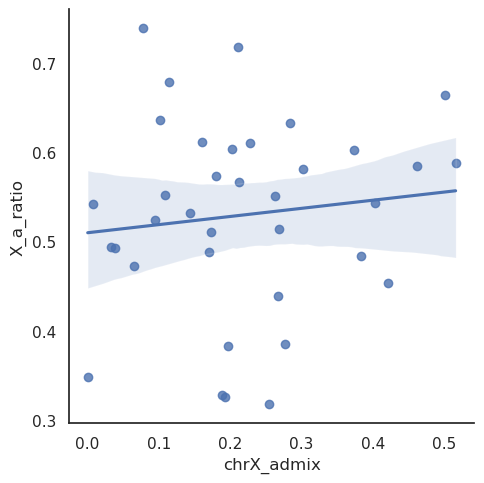

In [27]:
sns.lmplot(mean_pi_df, x="chrX_admix", y="X_a_ratio")

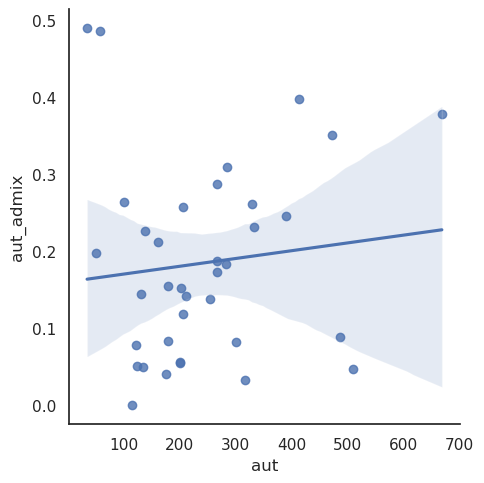

In [28]:
sns.lmplot(mean_pi_df, y="aut_admix", x="aut")

Last check - a species with a lot of identified admixture.

In [30]:
passing_df

,ID,ID_PGDP,group,family,genus,species,subspecies,species_full,species_short,species_genotyping,...,reason,finalQC,Kuderna_AB_QC,Kuderna_COV_QC,relatives,remove_as_relative,generation,founder,remove_manual,pedigree_source
2,SAMN15801446,SAMN15801446,OWM,Cercopithecidae,Allenopithecus,nigroviridis,ssp,Allenopithecus_nigroviridis_ssp,A.nigroviridis_ssp,Allenopithecus_nigroviridis_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,SAMN08978235,SAMN08978235,PLA,Aotidae,Aotus,nancymaae,ssp,Aotus_nancymaae_ssp,A.nancymaae_ssp,Aotus_nancymaae_ssp,...,NaN,ok,NaN,NaN,SAMN08978237,False,P,True,NaN,30270182
52,PD_0008,PD_0008,PLA,Aotidae,Aotus,trivirgatus,ssp,Aotus_trivirgatus_ssp,A.trivirgatus_ssp,Aotus_trivirgatus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,PD_0415,PD_0415,PLA,Atelidae,Alouatta,belzebul,ssp,Alouatta_belzebul_ssp,A.belzebul_ssp,Alouatta_belzebul_ssp,...,NaN,ok,NaN,NaN,PD_0296,False,NaN,NaN,NaN,NaN
63,PD_0027,PD_0027,PLA,Atelidae,Alouatta,discolor,ssp,Alouatta_discolor_ssp,A.discolor_ssp,Alouatta_discolor_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,PD_0420,PD_0420,PLA,Atelidae,Alouatta,juara,ssp,Alouatta_juara_ssp,A.juara_ssp,Alouatta_juara_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,PD_0135,PD_0135,PLA,Atelidae,Alouatta,macconnelli,ssp,Alouatta_macconnelli_ssp,A.macconnelli_ssp,Alouatta_macconnelli_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,PD_0175,PD_0175,PLA,Atelidae,Alouatta,palliata,ssp,Alouatta_palliata_ssp,A.palliata_ssp,Alouatta_palliata_ssp,...,NaN,warn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,PD_0430,PD_0430,PLA,Atelidae,Alouatta,seniculus,puruensis,Alouatta_seniculus_puruensis,A.seniculus_puruensis,Alouatta_seniculus_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,PD_0138,PD_0138,PLA,Atelidae,Ateles,belzebuth,ssp,Ateles_belzebuth_ssp,A.belzebuth_ssp,Ateles_belzebuth_ssp,...,NaN,ok,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
for ind in passing_df.loc[passing_df.ID == "PD_0032"].ID[:]:
    species = passing_df.loc[passing_df.ID == ind]["species_genotyping"].iloc[0]
    print(species)
    # Aut check
    structured_files = glob.glob(f'../steps/cobraa/{ind}/chrX_PSMC_D50_ts*_te*_final_parameters.txt')
    zte, zts, ztheta, zrho, zgamma, lambdaA_parameters, lambdaB_parameters, best_param_file = find_best(structured_files)
    for chrX in glob.glob(f"../steps/cobraa/{ind}/chrX_*decode.txt")[:5]:
        decode_position, posterior, prob_AA_marginal, prob_BB_marginal, prob_AB_marginal = decode_posterior_condition_t1(zte, zts, chrX)

Cercopithecus_ascanius_ssp


In [34]:
prob_BB_marginal.argmax()

11058

In [41]:
start = 10000
end = 12000
num_xticks = 5
step_size = 400

xtickslocs = np.linspace(start,end,num_xticks) - start
xtickslabs = [i for i in np.linspace(start,end,num_xticks)*step_size]

plt.rcParams['figure.figsize'] = [24, 12] 
plt.rcParams.update({'font.size': 25})

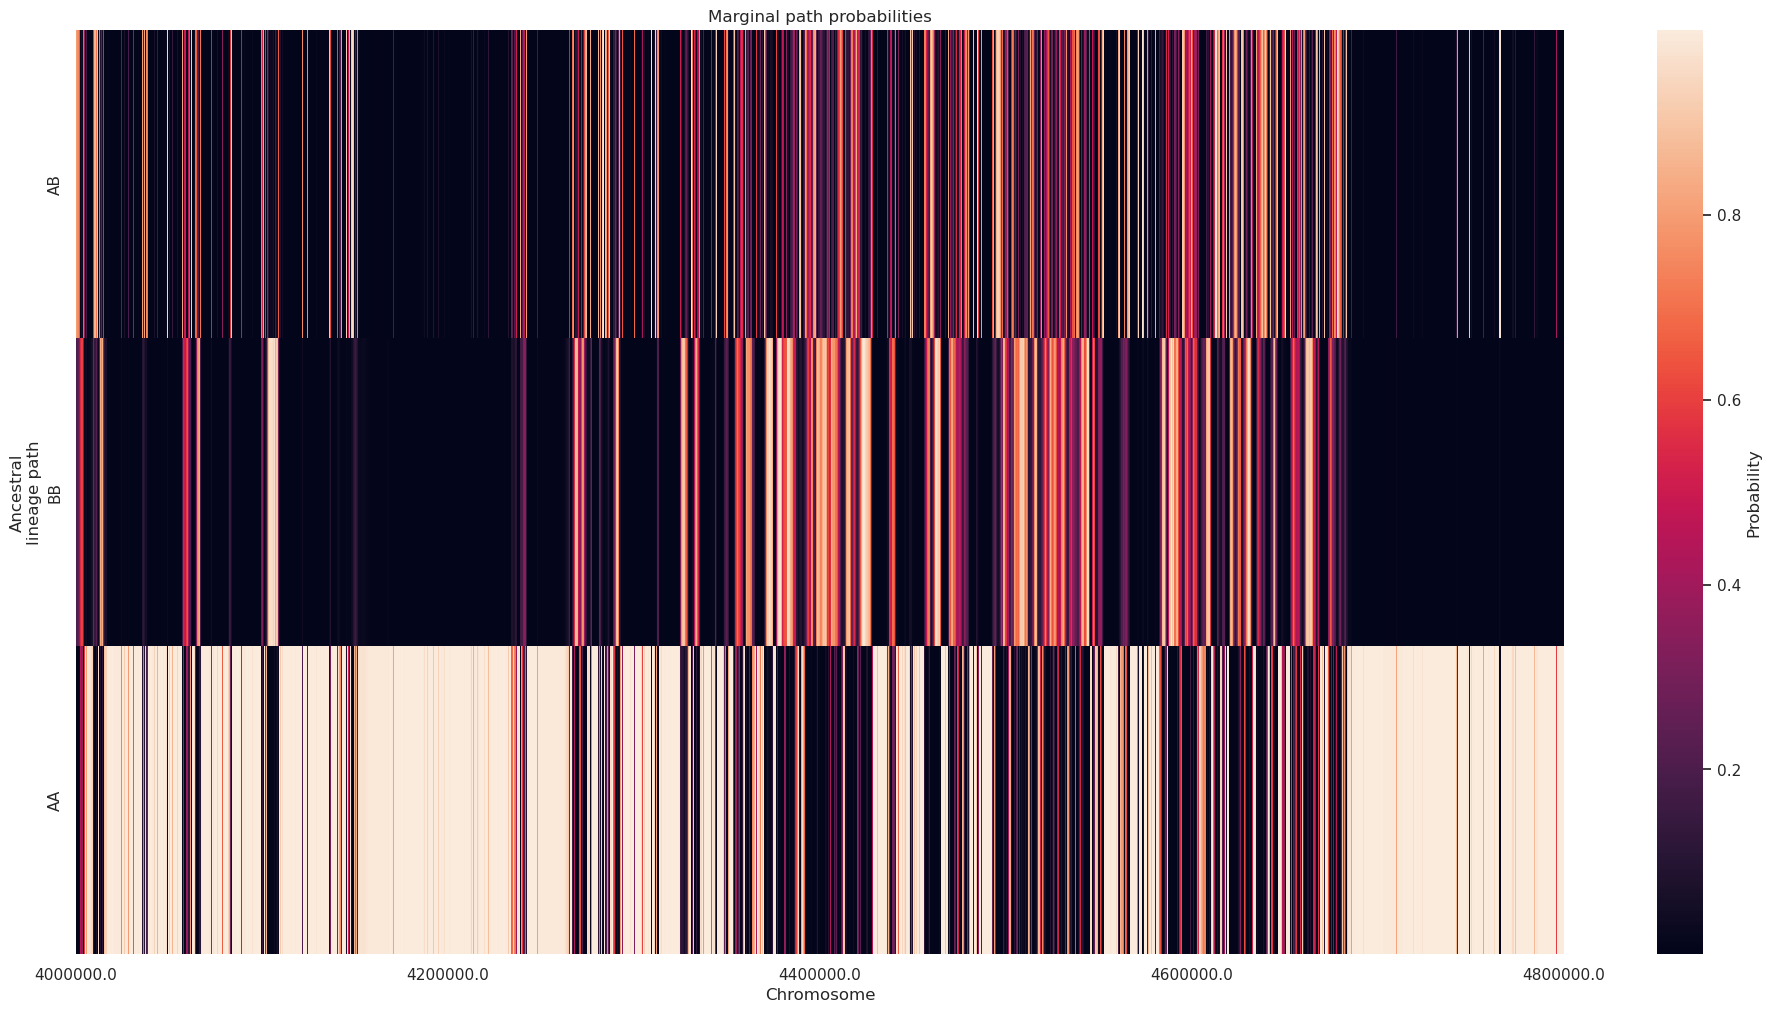

In [42]:
probs = np.array([prob_AA_marginal,prob_BB_marginal,prob_AB_marginal])
ax = sns.heatmap(probs[:,start:end],cbar_kws={'label': 'Probability'})
# ax.set_yticks(ticks=ydom,labels=yticks_labs,rotation='horizontal')
ax.set_xticks(ticks=xtickslocs,labels=xtickslabs,rotation='horizontal')
ax.set_xlabel('Chromosome')
ax.set_ylabel('Ancestral\nlineage path')
plt.yticks([0.5,1.5,2.5],['AA','BB','AB'])
ax.invert_yaxis()
ax.set_title('Marginal path probabilities')
plt.show()